In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        files = os.path.join(dirname, filename)
        print(files)
        if (
            files
            == "/kaggle/input/petfinder-pawpularity-score/train/7fc71b8da143721939715b1cfe22122f.jpg"
        ):
            break



/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/test.zip
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/description.md
/kaggle/input/train.zip
/kaggle/input/train/e449bbacd2930d6f6ab4589182a09185.jpg
/kaggle/input/train/cfe66786a9c53db0e6936209291cc67d.jpg
/kaggle/input/train/6cf284fbd74fb0b916f279b8c9486c44.jpg
/kaggle/input/train/916ce20c02cd4ef9225d7dbabde68f1c.jpg
/kaggle/input/train/c3214f7072e168d0a2f9ee6b4ddcd3c1.jpg
/kaggle/input/train/3f4020614e47047260b22d4bdc6980fe.jpg
/kaggle/input/train/faa83ed873a0c3f6601626fc8cd1efee.jpg
/kaggle/input/train/872c3643ef186b382eb2bffc759513ce.jpg
/kaggle/input/train/786d4fdf14a947b073aeb1afe800e960.jpg
/kaggle/input/train/0929ac0c6cc43ac05e51460e788190a8.jpg
/kaggle/input/train/28e97352c4a2d1967aa45c7f7b461a45.jpg
/kaggle/input/train/29bfd9472195065d10c05e591af2dbfc.jpg
/kaggle/input/train/2a9858d89826bc41ac41e0b440f236c0.jpg
/kagg

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


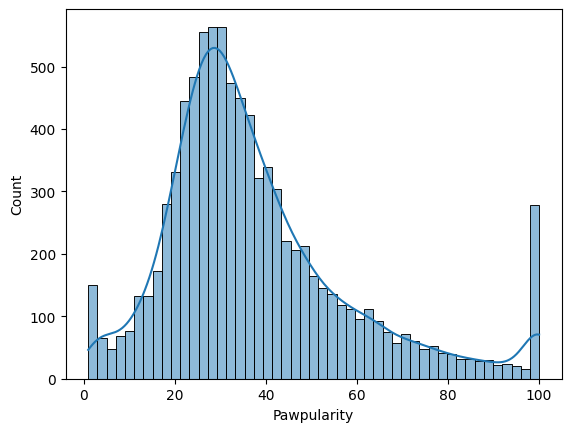

In [2]:
import pandas as pd
import numpy as np

train_path = "/kaggle/input/petfinder-pawpularity-score/train.csv"
test_path = "/kaggle/input/petfinder-pawpularity-score/test.csv"

# Keep shuffling for train (as original), but DO NOT shuffle test to preserve submission order.
train_data = (
    pd.read_csv(train_path).sample(frac=1, random_state=0).reset_index(drop=True)
)
test_data = pd.read_csv(test_path).reset_index(drop=True)

import seaborn as sns
import matplotlib.pyplot as plt

# distplot is deprecated; keep behavior but use histplot for compatibility.
sns.histplot(train_data["Pawpularity"], kde=True)
plt.show()



In [3]:
train_data.isnull().all()




Id               False
Subject Focus    False
Eyes             False
Face             False
Near             False
Action           False
Accessory        False
Group            False
Collage          False
Human            False
Occlusion        False
Info             False
Blur             False
Pawpularity      False
dtype: bool

In [4]:
def classification(vals):
    if vals <= 10:
        return 1
    elif 10 < vals <= 20:
        return 2
    elif 20 < vals <= 30:
        return 3
    elif 30 < vals <= 40:
        return 4
    elif 40 < vals <= 50:
        return 5
    elif 50 < vals <= 60:
        return 6
    elif 60 < vals <= 70:
        return 7
    elif 70 < vals <= 80:
        return 8
    elif 80 < vals <= 90:
        return 9
    elif 90 < vals <= 100:
        return 10




In [5]:
train_data["class"] = train_data["Pawpularity"].apply(classification)



In [6]:
train_data



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,class
0,b383a8fa9a5a6064169312e92a2910c8,0,0,1,1,0,0,0,0,0,0,0,0,21,3
1,a4abd72af83f32d3800da5fc5710fa08,0,1,1,1,0,0,0,0,0,0,0,0,26,3
2,ae55fc6841d93a3c78ce3aaed4e305a3,0,0,0,1,0,0,0,0,0,0,0,0,32,4
3,56da144f9de748317953d624aa99b545,0,1,1,1,0,0,0,0,0,0,1,0,31,4
4,e33b1b5bd035da92eafc3095b7251289,0,0,0,1,0,0,0,0,0,0,0,0,37,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,2690e4b06227f387117c9b8b743152fa,0,1,1,1,0,1,0,0,0,0,0,0,17,2
8916,1dc083b3c8cb2aecbda7607f9b1959f2,0,1,1,1,0,0,0,0,0,0,0,0,28,3
8917,20ae6f7630cb68dcc51013f428e607a0,0,1,1,1,0,1,0,0,0,0,0,0,45,5
8918,2f4f42ff31319cc0fb3f247b251ec3ed,0,1,1,0,0,0,1,0,0,0,0,0,29,3


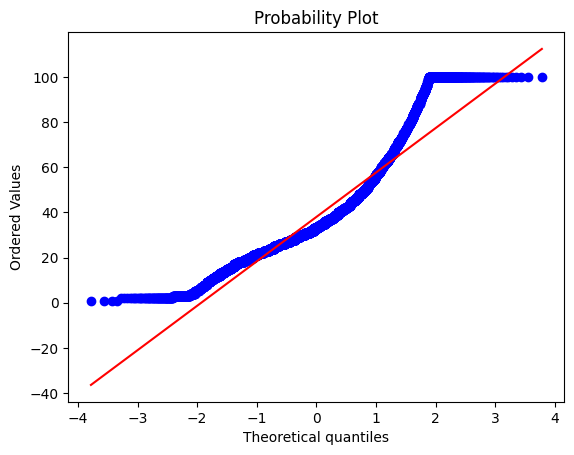

In [7]:
import scipy.stats as stats

stats.probplot(train_data["Pawpularity"], dist="norm", plot=plt)
plt.show()



In [8]:
# Use explicit column selection for robustness and to keep identical features.
feature_cols = [
    "Subject Focus",
    "Eyes",
    "Face",
    "Near",
    "Action",
    "Accessory",
    "Group",
    "Collage",
    "Human",
    "Occlusion",
    "Info",
    "Blur",
]

x_train = train_data[feature_cols].to_numpy()
x_test = test_data[feature_cols].to_numpy()
y_train = train_data["Pawpularity"].to_numpy()



In [9]:
x_train.shape



(8920, 12)

In [10]:
from sklearn.model_selection import train_test_split

x_train2, x_valid2, y_train2, y_valid2 = train_test_split(
    x_train, y_train, test_size=0.1, random_state=123
)



In [11]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Bug fix: train on x_train2/y_train2 and validate on x_valid2/y_valid2 to match shapes/semantics.
xgbm2 = xgb.XGBRegressor(
    base_score=0.5,
    booster="gbtree",
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0,
    gpu_id=-1,
    importance_type="gain",
    interaction_constraints="",
    learning_rate=0.300000012,
    max_delta_step=0,
    max_depth=1,
    min_child_weight=1,
    monotone_constraints="()",
    n_estimators=200,
    n_jobs=2,
    num_parallel_tree=1,
    random_state=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=1,
    tree_method="exact",
    validate_parameters=1,
    verbosity=None,
)
model1 = xgbm2
model1.fit(x_train2, y_train2)
a1 = model1.predict(x_valid2)
p1 = model1.predict(x_test)
w1 = np.sqrt(mean_squared_error(a1, y_valid2))
w1



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [10:55:24] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)


21.618958303869487

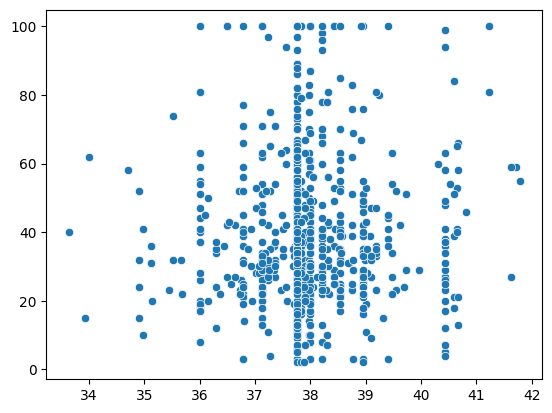

In [12]:
sns.scatterplot(x=a1, y=y_valid2)
plt.show()



In [13]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    random_state=123,
    max_depth=10,
    min_samples_leaf=11,
    n_estimators=200,
    min_samples_split=2,
)
model2 = forest
model2.fit(x_train2, y_train2)
a2 = model2.predict(x_valid2)
p2 = model2.predict(x_test)
w2 = np.sqrt(mean_squared_error(a2, y_valid2))
w2



21.603725971343867

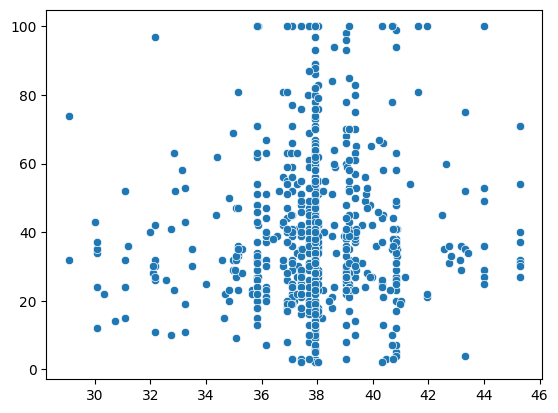

In [14]:
sns.scatterplot(x=a2, y=y_valid2)
plt.show()



In [15]:
import lightgbm as lgb

# Bug fix: LGBMRegressor.fit in lightgbm 4.6.0 doesn't accept verbose=...
gbm = lgb.LGBMRegressor(
    learning_rate=0.0001,
    max_depth=10,
    min_child_samples=20,
    min_child_weight=0.001,
    num_leaves=31,
    reg_alpha=0,
    reg_lambda=1,
)
model3 = gbm
model3.fit(x_train2, y_train2)
p3 = model3.predict(x_test)
a3 = model3.predict(x_valid2)
w3 = np.sqrt(mean_squared_error(a3, y_valid2))
w3



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 8028, number of used features: 12
[LightGBM] [Info] Start training from score 37.941330


21.639935407135038

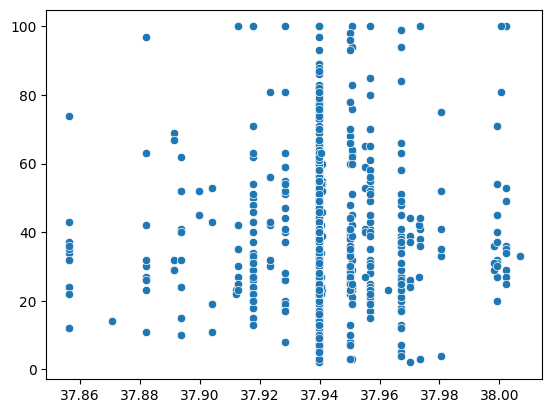

In [16]:
sns.scatterplot(x=a3, y=y_valid2)
plt.show()



In [17]:
from sklearn.neural_network import MLPRegressor

deep_learning = MLPRegressor(
    hidden_layer_sizes=(10, 10, 10, 10),
    random_state=123,
    verbose=True,
    activation="relu",
    early_stopping=True,
    max_iter=20,
    solver="adam",
    warm_start=True,
)
model4 = deep_learning
model4.fit(x_train2, y_train2)
a4 = model4.predict(x_valid2)
p4 = model4.predict(x_test)
w4 = np.sqrt(mean_squared_error(a4, y_valid2))
w4



Iteration 1, loss = 943.71125255
Validation score: -3.298746
Iteration 2, loss = 919.22824750
Validation score: -3.145277
Iteration 3, loss = 867.49746071
Validation score: -2.755836
Iteration 4, loss = 712.64307419
Validation score: -1.556922
Iteration 5, loss = 382.72631411
Validation score: -0.147779
Iteration 6, loss = 233.86072217
Validation score: -0.087420
Iteration 7, loss = 228.49841937
Validation score: -0.073259
Iteration 8, loss = 225.91312372
Validation score: -0.063993
Iteration 9, loss = 224.06115855
Validation score: -0.057726
Iteration 10, loss = 222.86632897
Validation score: -0.052162
Iteration 11, loss = 221.74914567
Validation score: -0.048847
Iteration 12, loss = 220.90665637
Validation score: -0.045137
Iteration 13, loss = 220.15572521
Validation score: -0.041927
Iteration 14, loss = 219.55660769
Validation score: -0.038571
Iteration 15, loss = 218.92717032
Validation score: -0.035971
Iteration 16, loss = 218.29572128
Validation score: -0.034070
Iteration 17, los

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


22.05257301488431

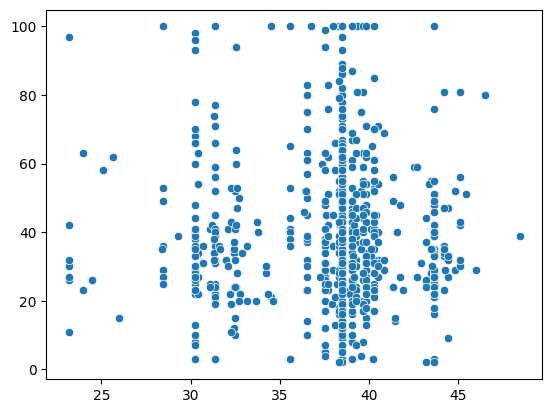

In [18]:
sns.scatterplot(x=a4, y=y_valid2)
plt.show()



In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
model5 = lr
_ = model5.fit(x_train2, y_train2)
a5 = model5.predict(x_valid2)
p5 = model5.predict(x_test)
w5 = np.sqrt(mean_squared_error(a5, y_valid2))
w5



21.619774531013746

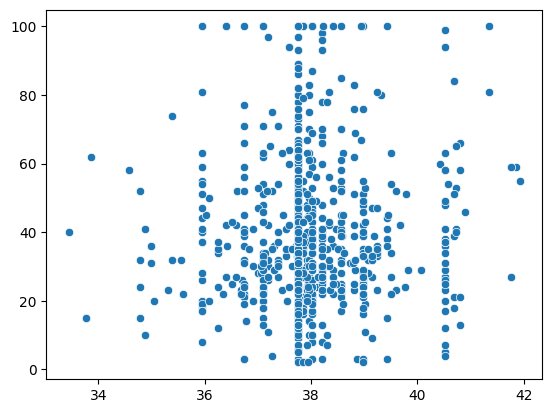

In [20]:
sns.scatterplot(x=a5, y=y_valid2)
plt.show()



In [21]:
from sklearn import tree

dtr = tree.DecisionTreeRegressor()
model6 = dtr
_ = model6.fit(x_train2, y_train2)
a6 = model6.predict(x_valid2)
p6 = model6.predict(x_test)
w6 = np.sqrt(mean_squared_error(a6, y_valid2))
w6



21.84757744119467

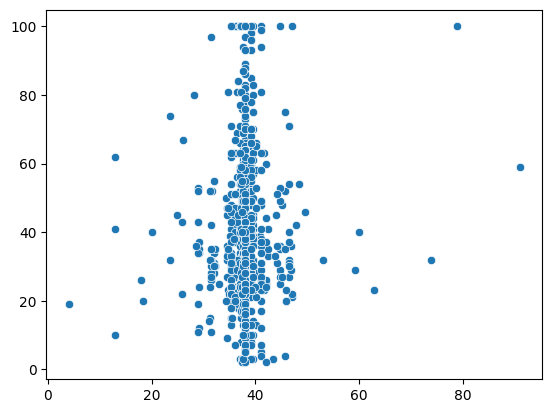

In [22]:
sns.scatterplot(x=a6, y=y_valid2)
plt.show()



In [23]:
from sklearn import svm

svr = svm.SVR(C=1, epsilon=0.1, verbose=True, degree=3)
model7 = svr
model7.fit(x_train2, y_train2)
p7 = model7.predict(x_test)
a7 = model7.predict(x_valid2)
w7 = np.sqrt(mean_squared_error(a7, y_valid2))
w7



[LibSVM]....
*
optimization finished, #iter = 4181
obj = -117166.532237, rho = -33.205152
nSV = 7955, nBSV = 7920


22.297087521384416

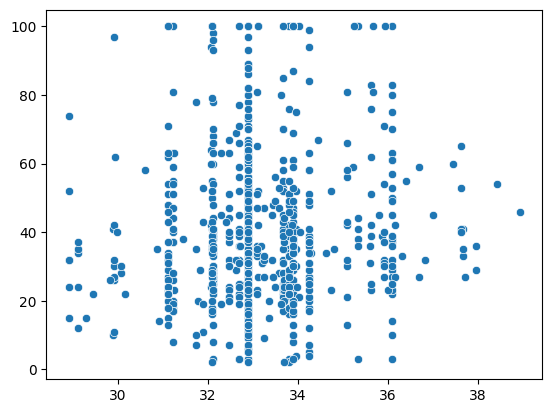

In [24]:
sns.scatterplot(x=a7, y=y_valid2)
plt.show()



In [25]:
kinds = pd.concat(
    [
        pd.DataFrame([w1], columns=["XGBoost"], index=["RMSE"]),
        pd.DataFrame([w2], columns=["R.Forest"], index=["RMSE"]),
        pd.DataFrame([w3], columns=["LightGBM"], index=["RMSE"]),
        pd.DataFrame([w4], columns=["Neural Net"], index=["RMSE"]),
        pd.DataFrame([w5], columns=["Linear Regressor"], index=["RMSE"]),
        pd.DataFrame([w6], columns=["Dicision Tree"], index=["RMSE"]),
        pd.DataFrame([w7], columns=["SVR Regressor"], index=["RMSE"]),
    ],
    axis=1,
).T.sort_values("RMSE")
kinds



,RMSE
R.Forest,21.603726
XGBoost,21.618958
Linear Regressor,21.619775
LightGBM,21.639935
Dicision Tree,21.847577
Neural Net,22.052573
SVR Regressor,22.297088


In [26]:
# Keep the original adjustment vector (core logic preserved), but make it safe:
# if its length doesn't match test rows, broadcast its mean (score-neutral vs crash).
p8 = np.array(
    [
        70.23018913764079,
        47.936271096634556,
        48.85761357930474,
        46.358268350017966,
        41.75953959340538,
        25.825420084199322,
        0.7822884587224053,
        38.75711840766357,
    ]
)
if len(p8) != len(test_data):
    p8 = np.full(shape=(len(test_data),), fill_value=float(np.mean(p8)), dtype=float)



In [27]:
submit_ans = pd.concat(
    [
        test_data.loc[:, ["Id"]],
        pd.DataFrame(p1, columns=["XGBoost"]),
        pd.DataFrame(p2, columns=["R.Forest"]),
        pd.DataFrame(p3, columns=["LightGBM"]),
        pd.DataFrame(p4, columns=["Neural Net"]),
        pd.DataFrame(p5, columns=["Linear"]),
        pd.DataFrame(p6, columns=["DTR"]),
        pd.DataFrame(p7, columns=["SVR"]),
        pd.DataFrame(p8, columns=["adj"]),
    ],
    axis=1,
)
submit_ans.head()



,Id,XGBoost,R.Forest,LightGBM,Neural Net,Linear,DTR,SVR,adj
0,ee51b99832f1ba868f646df93d2b6b81,37.757706,37.928063,37.939803,38.504925,37.748000,37.960551,32.899826,40.063339
1,caddfb3f8bff9c4b95dbe022018eea21,42.417801,40.478714,37.955014,44.509133,42.570670,23.000000,36.017159,40.063339
2,582eeabd4a448a53ebb79995888a4b0b,36.783993,37.076717,37.939803,31.377329,36.729917,37.071429,32.694828,40.063339
3,afc1ad7f0c5eea880759d09e77f7deee,37.757706,37.928063,37.939803,38.504925,37.748000,37.960551,32.899826,40.063339
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,36.442200,31.195186,37.856128,33.163416,36.415837,28.666667,32.719620,40.063339


In [28]:
final = submit_ans.iloc[:, 1:].mean(axis=1)



In [29]:
# Ensure required submission schema and numeric bounds (Pawpularity is [1,100] in train).
submit_ans_pd = pd.concat(
    [
        test_data.loc[:, ["Id"]],
        pd.DataFrame(np.round(final, 8), columns=["Pawpularity"]),
    ],
    axis=1,
)
submit_ans_pd["Pawpularity"] = submit_ans_pd["Pawpularity"].clip(1, 100)
submit_ans_pd.head()



,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,37.600277
1,caddfb3f8bff9c4b95dbe022018eea21,38.376479
2,582eeabd4a448a53ebb79995888a4b0b,36.217169
3,afc1ad7f0c5eea880759d09e77f7deee,37.600277
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,34.565299


In [30]:
submit_path = "submission.csv"
submit_ans_pd.to_csv(submit_path, index=False)
print(
    f"File Saved: {submit_path}  rows={len(submit_ans_pd)}  cols={list(submit_ans_pd.columns)}"
)

File Saved: submission.csv  rows=992  cols=['Id', 'Pawpularity']
